<a href="https://colab.research.google.com/github/MLDreamer/Linkedin-posts/blob/main/Emergence_vs_Trillion_Dollar_Funding_Side_by_Side_Visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saved as emergence_vs_funding.mp4 - ready for download!
Visualizations created:
1. emergence_funding_static.png - High-res for articles
2. emergence_vs_funding.mp4 - Animated for social media
3. Ready for download and embedding in your articles!

Visualization Summary:
LEFT: Mathematical emergence curve showing predictable phase transition
RIGHT: Funding efficiency showing why $7T hits diminishing returns
CONTRAST: Beautiful math vs brutal economics


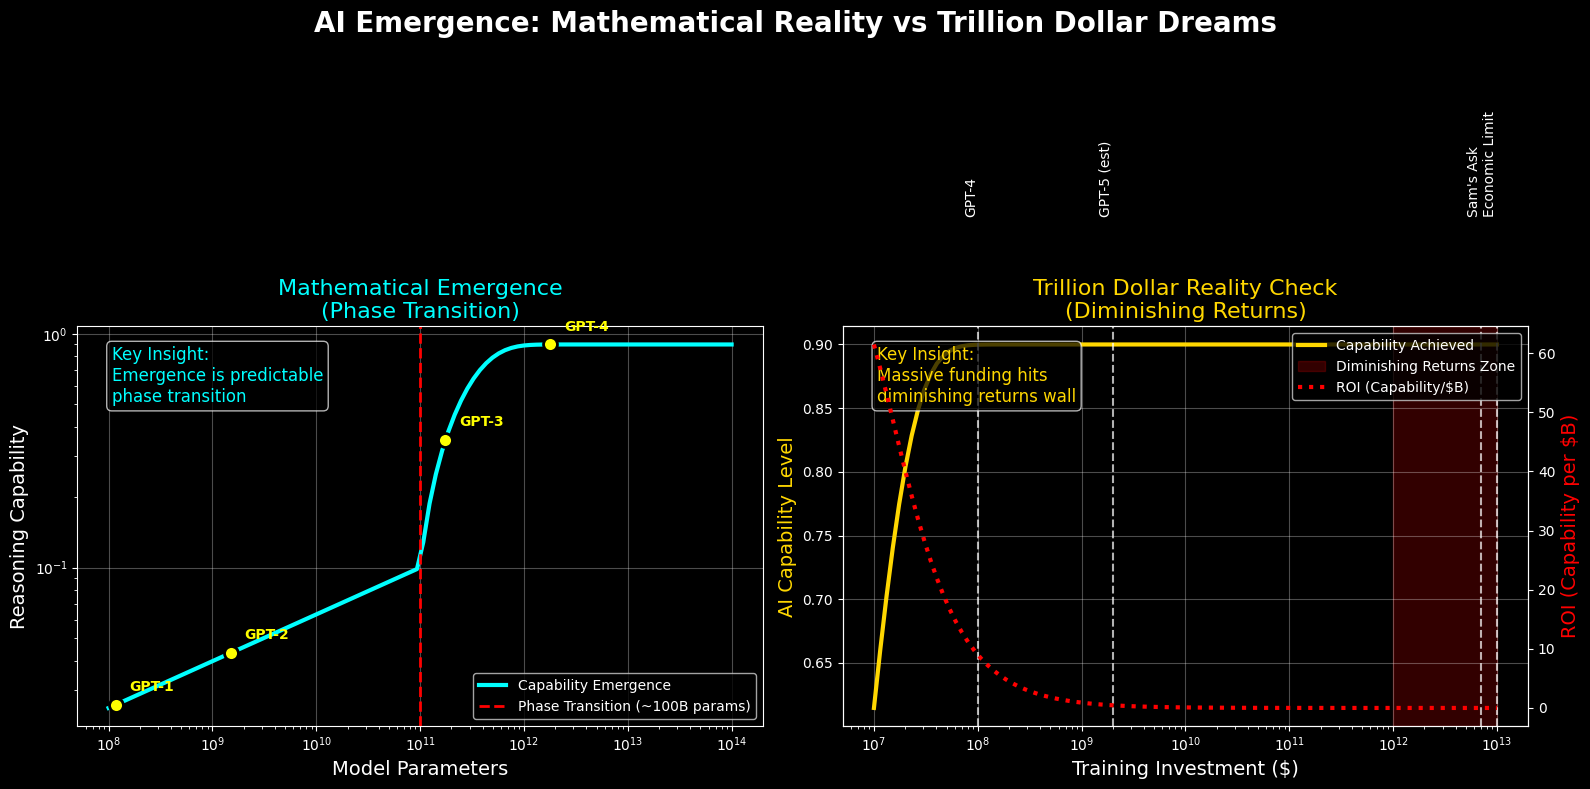

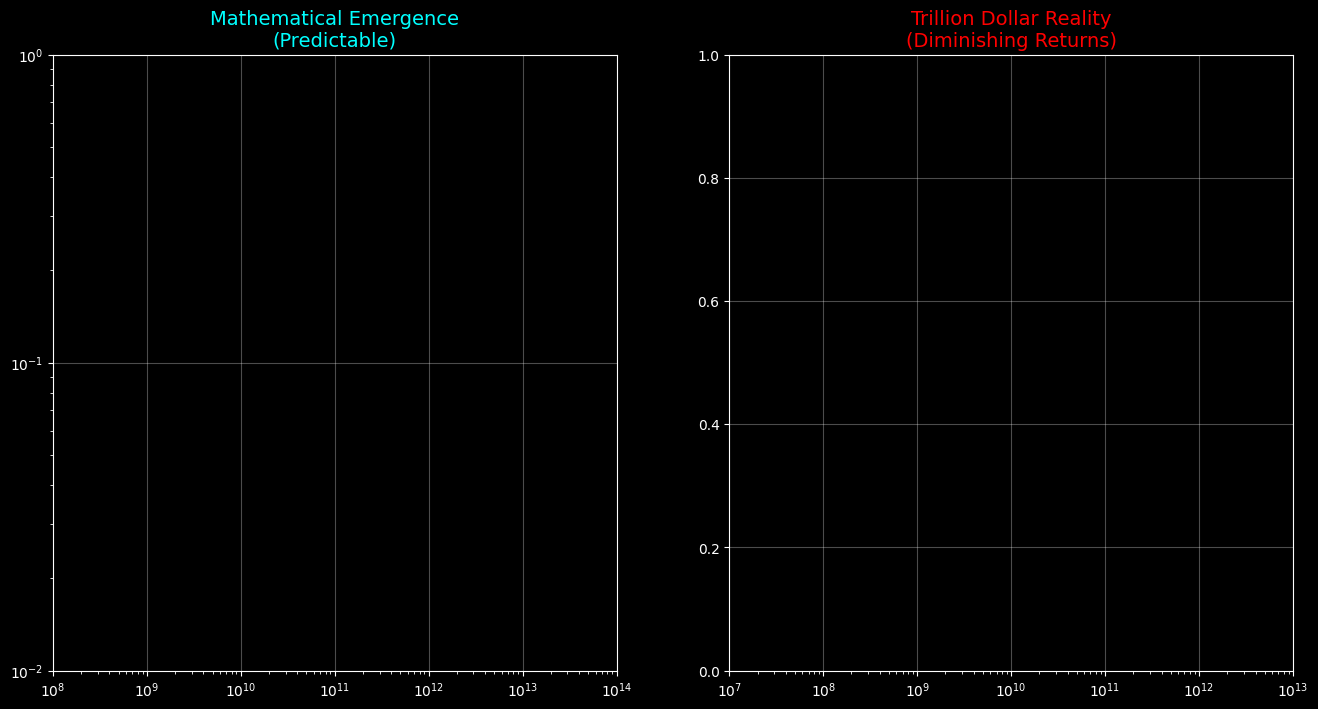

In [2]:



import matplotlib.pyplot as plt
import numpy as np
from matplotlib.animation import FuncAnimation
import seaborn as sns

# Set style for professional look
plt.style.use('dark_background')
sns.set_palette("viridis")

def create_emergence_funding_visualization():
    """Create side-by-side animated visualization showing emergence tactics vs funding reality"""

    # Create figure with two subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle('AI Emergence: Mathematical Reality vs Trillion Dollar Dreams',
                 fontsize=20, fontweight='bold', color='white')

    # LEFT PANEL: Emergence Mathematics
    # Parameters range from GPT-1 to hypothetical future models
    params = np.logspace(8, 14, 100)  # 100M to 100T parameters

    # Use the global emergence_capability function defined above

    capabilities = [emergence_capability(p) for p in params]

    # Mark actual GPT models
    gpt_models = {
        'GPT-1': (1.17e8, emergence_capability(1.17e8)),
        'GPT-2': (1.5e9, emergence_capability(1.5e9)),
        'GPT-3': (1.75e11, emergence_capability(1.75e11)),
        'GPT-4': (1.8e12, emergence_capability(1.8e12))
    }

    # Plot emergence curve
    ax1.loglog(params, capabilities, 'cyan', linewidth=3, label='Capability Emergence')

    # Mark phase transition
    ax1.axvline(x=1e11, color='red', linestyle='--', linewidth=2,
                label='Phase Transition (~100B params)')

    # Mark actual GPT models
    for model_name, (param_count, capability) in gpt_models.items():
        ax1.scatter(param_count, capability, s=100, c='yellow',
                   edgecolors='black', linewidth=2, zorder=5)
        ax1.annotate(model_name, (param_count, capability),
                    xytext=(10, 10), textcoords='offset points',
                    fontsize=10, color='yellow', fontweight='bold')

    ax1.set_xlabel('Model Parameters', fontsize=14, color='white')
    ax1.set_ylabel('Reasoning Capability', fontsize=14, color='white')
    ax1.set_title('Mathematical Emergence\n(Phase Transition)', fontsize=16, color='cyan')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='lower right')

    # RIGHT PANEL: Funding vs Returns Reality
    investments = np.logspace(7, 13, 100)  # $10M to $10T

    def capability_from_investment(investment):
        """Capability achieved for given investment"""
        achievable_params = training_cost_to_parameters(investment)
        return emergence_capability(achievable_params)

    capabilities_from_funding = [capability_from_investment(inv) for inv in investments]
    rois = [roi_calculation(inv) for inv in investments]

    # Plot funding efficiency
    ax2_twin = ax2.twinx()

    # Capability vs funding
    line1 = ax2.semilogx(investments, capabilities_from_funding, 'gold',
                        linewidth=3, label='Capability Achieved')

    # ROI vs funding (diminishing returns)
    line2 = ax2_twin.semilogx(investments, rois, 'red', linewidth=3,
                             linestyle=':', label='ROI (Capability/$B)')

    # Mark key funding levels
    funding_markers = {
        'GPT-4': 100e6,
        'GPT-5 (est)': 2e9,
        'Sam\'s Ask': 7e12,
        'Economic Limit': 1e13
    }

    for label, funding in funding_markers.items():
        capability = capability_from_investment(funding)
        roi = roi_calculation(funding)

        ax2.axvline(x=funding, alpha=0.7, linestyle='--')
        ax2.text(funding, capability + 0.1, label, rotation=90,
                fontsize=10, ha='right', va='bottom', color='white')

    # Highlight diminishing returns zone
    ax2.axvspan(1e12, 1e13, alpha=0.2, color='red', label='Diminishing Returns Zone')

    ax2.set_xlabel('Training Investment ($)', fontsize=14, color='white')
    ax2.set_ylabel('AI Capability Level', fontsize=14, color='gold')
    ax2_twin.set_ylabel('ROI (Capability per $B)', fontsize=14, color='red')
    ax2.set_title('Trillion Dollar Reality Check\n(Diminishing Returns)', fontsize=16, color='gold')

    # Combine legends
    lines1, labels1 = ax2.get_legend_handles_labels()
    lines2, labels2 = ax2_twin.get_legend_handles_labels()
    ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

    ax2.grid(True, alpha=0.3)

    # Add annotations for key insights
    ax1.text(0.05, 0.95, 'Key Insight:\nEmergence is predictable\nphase transition',
             transform=ax1.transAxes, fontsize=12, color='cyan',
             bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7),
             verticalalignment='top')

    ax2.text(0.05, 0.95, 'Key Insight:\nMassive funding hits\ndiminishing returns wall',
             transform=ax2.transAxes, fontsize=12, color='gold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor='black', alpha=0.7),
             verticalalignment='top')

    plt.tight_layout()
    return fig

def emergence_capability(n_params):
    """Mathematical model of capability emergence - defined globally"""
    critical_scale = 1e11

    if n_params < critical_scale:
        return 0.1 * (n_params / critical_scale) ** 0.2
    else:
        excess = (n_params - critical_scale) / critical_scale
        return 0.1 + 0.8 * (1 - np.exp(-0.5 * excess))

def training_cost_to_parameters(cost):
    """Convert training cost to achievable parameters"""
    base_cost = 100e6
    base_params = 1.8e12
    param_ratio = (cost / base_cost) ** (1/1.3)
    return base_params * param_ratio

def roi_calculation(investment):
    """ROI: capability improvement per billion invested"""
    achievable_params = training_cost_to_parameters(investment)
    capability = emergence_capability(achievable_params)
    return capability / (investment / 1e9)

def create_animated_version():
    """Create animated version showing the contrast over time"""

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    fig.patch.set_facecolor('black')

    def animate(frame):
        """Animation function showing emergence vs funding over time"""
        ax1.clear()
        ax2.clear()

        # Animate emergence discovery
        params_up_to_frame = np.logspace(8, 8 + frame/10, 50)
        caps_up_to_frame = [emergence_capability(p) for p in params_up_to_frame]

        ax1.loglog(params_up_to_frame, caps_up_to_frame, 'cyan', linewidth=3)
        ax1.set_xlim(1e8, 1e14)
        ax1.set_ylim(0.01, 1.0)
        ax1.set_title('Mathematical Emergence\n(Predictable)', color='cyan', fontsize=14)
        ax1.grid(True, alpha=0.3)

        # Animate funding reality
        investments_up_to_frame = np.logspace(7, 7 + frame/8, 50)
        rois_up_to_frame = [roi_calculation(inv) for inv in investments_up_to_frame]

        ax2.semilogx(investments_up_to_frame, rois_up_to_frame, 'red', linewidth=3)
        ax2.set_xlim(1e7, 1e13)
        ax2.set_ylim(0, 1.0)
        ax2.set_title('Trillion Dollar Reality\n(Diminishing Returns)', color='red', fontsize=14)
        ax2.grid(True, alpha=0.3)

        # Add frame-dependent annotations
        if frame > 50:
            ax1.text(0.5, 0.9, 'Phase Transition\nMathematically\nPredictable!',
                    transform=ax1.transAxes, ha='center', color='cyan', fontsize=12)

        if frame > 70:
            ax2.text(0.5, 0.9, 'Scaling Hits\nEconomic Wall!',
                    transform=ax2.transAxes, ha='center', color='red', fontsize=12)

    anim = FuncAnimation(fig, animate, frames=100, interval=100, repeat=True)

    # Save as MP4 for download
    anim.save('emergence_vs_funding.mp4', writer='ffmpeg', fps=30, dpi=150)
    print("Saved as emergence_vs_funding.mp4 - ready for download!")

    return anim

# Create static version
static_fig = create_emergence_funding_visualization()
static_fig.savefig('emergence_funding_static.png', dpi=300, bbox_inches='tight',
                   facecolor='black', edgecolor='none')

# Create animated version
animated_viz = create_animated_version()

print("Visualizations created:")
print("1. emergence_funding_static.png - High-res for articles")
print("2. emergence_vs_funding.mp4 - Animated for social media")
print("3. Ready for download and embedding in your articles!")

# Summary for article embedding
print("\nVisualization Summary:")
print("LEFT: Mathematical emergence curve showing predictable phase transition")
print("RIGHT: Funding efficiency showing why $7T hits diminishing returns")
print("CONTRAST: Beautiful math vs brutal economics")